# INSTALL AND IMPORT LIBRARIES

In [ ]:
!pip install vaderSentiment
!pip install surprise
!pip install "numpy<2.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 7.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 6.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554963 sha256=e50e43942e4ca259322ca2c99177e5f86723aed484914737e2966f70f7fb363b
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 91.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all

In [ ]:
# Basic libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings


# Sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Utilities
import joblib
import random

# sklearn ML tools
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, RepeatedKFold, train_test_split as sklearn_train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeRegressor

# Recommendation system
from surprise import Reader, Dataset, SVD, accuracy, BaselineOnly, SlopeOne
from surprise.model_selection import train_test_split, GridSearchCV, cross_validate

# Advanced ML
import xgboost as xgb

# Plotting config
warnings.filterwarnings("ignore")
warnings.simplefilter(action='ignore', category=FutureWarning)


# LOAD DATA SETS

In [ ]:
# load listings
listings_df = pd.read_csv('listings (1).csv.gz', compression='gzip')
listings_df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,44077,https://www.airbnb.com/rooms/44077,20250613040039,2025-06-13,city scrape,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,I like our neighbourhood as there is no shorta...,https://a0.muscache.com/pictures/525706/050a3a...,193005,...,4.93,4.68,4.82,NaN,f,2,0,2,0,2.19
1,85156,https://www.airbnb.com/rooms/85156,20250613040039,2025-06-13,city scrape,Cosy Comfortable Irish Cottage 1 Double Bed,Our Cottage is a charming light filled cottage...,"I love Dundrum and its surrounding areas ,<br ...",https://a0.muscache.com/pictures/1749253/9ed2a...,193005,...,4.89,4.64,4.78,NaN,f,2,0,2,0,2.00
2,159889,https://www.airbnb.com/rooms/159889,20250613040039,2025-06-13,city scrape,Friendly Single Room,Washing can be done at a cost of €5 per load....,Plenty of buses into the city and the area is ...,https://a0.muscache.com/pictures/3031697/a8259...,766611,...,4.87,4.65,4.71,NaN,f,3,0,3,0,2.79
3,162809,https://www.airbnb.com/rooms/162809,20250613040039,2025-06-13,previous scrape,5.5 miles south of Dublin City :^),A nice place to relax after the bustle of the ...,"Close to the sea, hill walks and the city - vi...",https://a0.muscache.com/pictures/86694529/c07b...,777681,...,4.97,4.78,4.85,NaN,f,2,0,2,0,3.22
4,165828,https://www.airbnb.com/rooms/165828,20250613040039,2025-06-13,city scrape,Pádraig Pearse apt. Kilmainham,"Don't just visit Dublin, experience Dublin in ...","Enjoy a walk along the grand canal, or just ob...",https://a0.muscache.com/pictures/34311419/b3f6...,790601,...,4.77,4.40,4.56,NaN,f,4,4,0,0,0.51


In [ ]:
listings_df['price'].isna().sum()

1386

In [ ]:
# load reviews
reviews_df = pd.read_csv('reviews.csv.gz', compression='gzip')
reviews_df.head()

,listing_id,id,date,reviewer_id,reviewer_name,comments
0,44077,203703,2011-03-20,393348,Christian,We enjoyed our stay very much. The room was co...
1,44077,211369,2011-03-28,444004,Solidea,We have been here 4 nights. Stay in a home is ...
2,44077,234215,2011-04-21,465058,Michael And Isabelle,Teresa and Hughie were great hosts. They were ...
3,44077,261843,2011-05-13,490005,Weston,"No surprises, was as described. Very gracious..."
4,44077,268148,2011-05-17,520460,Barbara,"Teresa was a lovely hostess, and we had a deli..."


In [ ]:
missing_pct = (reviews_df.isna().mean() * 100).round(2).astype(str) + '%'

print(missing_pct)

listing_id        0.0%
id                0.0%
date              0.0%
reviewer_id       0.0%
reviewer_name     0.0%
comments         0.01%
dtype: object


# DATA PREPROCESSING

Merging both datasets

In [ ]:
reviews_df.dropna(inplace=True)

In [ ]:
if listings_df['price'].dtype == 'object':
    listings_df['price'] = listings_df['price'].replace(r'[\$,]', '', regex=True).astype(float)

# drop missing values
listings_df = listings_df.dropna(subset=['price'])

In [ ]:
listings_df['price'].isna().sum()

0

In [ ]:
# check for outlier in price
listings_df['price'].describe()

,price
count,5395.000000
mean,200.905468
std,471.199496
min,16.000000
25%,85.000000
50%,134.000000
75%,225.000000
max,19140.000000


In [ ]:
dublin_merged_df = pd.merge(listings_df, reviews_df, left_on='id', right_on='listing_id')
dublin_merged_df.head(2)

,id_x,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,listing_id,id_y,date,reviewer_id,reviewer_name,comments
0,44077,https://www.airbnb.com/rooms/44077,20250613040039,2025-06-13,city scrape,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,I like our neighbourhood as there is no shorta...,https://a0.muscache.com/pictures/525706/050a3a...,193005,...,0,2,0,2.19,44077,203703,2011-03-20,393348,Christian,We enjoyed our stay very much. The room was co...
1,44077,https://www.airbnb.com/rooms/44077,20250613040039,2025-06-13,city scrape,cosy comfortable Irish cottage twin,Our house is a cosy comfortable cottage with ...,I like our neighbourhood as there is no shorta...,https://a0.muscache.com/pictures/525706/050a3a...,193005,...,0,2,0,2.19,44077,211369,2011-03-28,444004,Solidea,We have been here 4 nights. Stay in a home is ...


In [ ]:
dublin_merged_df.duplicated().sum()

0

Dimensionality Reduction and Dropping Irrelevant features

In [ ]:
columns_to_drop = [
    'scrape_id', 'last_scraped',
    'neighborhood_overview', 'host_url', 'availability_30', 'availability_60',
    'availability_90',
    'host_name', 'host_location', 'host_about', 'host_thumbnail_url',
    'host_picture_url', 'host_neighbourhood', 'host_verifications',
    'neighbourhood_group_cleansed', 'host_total_listings_count',
    'minimum_minimum_nights', 'maximum_minimum_nights', 'bathrooms_text', 'minimum_maximum_nights',
    'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm',
    'calendar_updated', 'neighbourhood_cleansed', 'calendar_last_scraped', 'number_of_reviews_ltm', 'license', 'has_availability',
    'host_id', 'source', 'calculated_host_listings_count', 'calculated_host_listings_count_entire_homes',
    'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms'
]

# Drop the specified columns
dublin_merged_df = dublin_merged_df.drop(columns=columns_to_drop)


In [ ]:
# check remaining columns
dublin_merged_df.columns

Index(['id_x', 'listing_url', 'name', 'description', 'picture_url',
       'host_since', 'host_response_time', 'host_response_rate',
       'host_acceptance_rate', 'host_is_superhost', 'host_listings_count',
       'host_has_profile_pic', 'host_identity_verified', 'neighbourhood',
       'latitude', 'longitude', 'property_type', 'room_type', 'accommodates',
       'bathrooms', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights',
       'maximum_nights', 'availability_365', 'number_of_reviews',
       'number_of_reviews_l30d', 'availability_eoy', 'number_of_reviews_ly',
       'estimated_occupancy_l365d', 'estimated_revenue_l365d', 'first_review',
       'last_review', 'review_scores_rating', 'review_scores_accuracy',
       'review_scores_cleanliness', 'review_scores_checkin',
       'review_scores_communication', 'review_scores_location',
       'review_scores_value', 'instant_bookable', 'reviews_per_month',
       'listing_id', 'id_y', 'date', 'reviewer_id', 'reviewer_name',
 

In [ ]:
dublin_merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276126 entries, 0 to 276125
Data columns (total 50 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_x                         276126 non-null  int64  
 1   listing_url                  276126 non-null  object 
 2   name                         276126 non-null  object 
 3   description                  272343 non-null  object 
 4   picture_url                  276126 non-null  object 
 5   host_since                   275863 non-null  object 
 6   host_response_time           267446 non-null  object 
 7   host_response_rate           267446 non-null  object 
 8   host_acceptance_rate         272306 non-null  object 
 9   host_is_superhost            268025 non-null  object 
 10  host_listings_count          275863 non-null  float64
 11  host_has_profile_pic         275863 non-null  object 
 12  host_identity_verified       275863 non-null  object 
 13 

In [ ]:
missing_pct = (dublin_merged_df.isna().mean() * 100).round(2).astype(str) + '%'

print(missing_pct)

id_x                             0.0%
listing_url                      0.0%
name                             0.0%
description                     1.37%
picture_url                      0.0%
host_since                       0.1%
host_response_time              3.14%
host_response_rate              3.14%
host_acceptance_rate            1.38%
host_is_superhost               2.93%
host_listings_count              0.1%
host_has_profile_pic             0.1%
host_identity_verified           0.1%
neighbourhood                  32.54%
latitude                         0.0%
longitude                        0.0%
property_type                    0.0%
room_type                        0.0%
accommodates                     0.0%
bathrooms                       0.02%
bedrooms                        0.03%
beds                            0.01%
amenities                        0.0%
price                            0.0%
minimum_nights                   0.0%
maximum_nights                   0.0%
availability

In [ ]:
dublin_merged_df.describe()

,id_x,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,listing_id,id_y,reviewer_id
count,2.761260e+05,275863.000000,276126.000000,276126.000000,276126.000000,276082.000000,276045.000000,276099.000000,276126.000000,276126.000000,...,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,2.761260e+05,2.761260e+05,2.761260e+05
mean,2.826350e+17,11.890261,53.354630,-6.253679,3.141540,1.248310,1.409111,2.025494,170.346679,3.655798,...,4.831430,4.775636,4.866982,4.886501,4.782667,4.682026,3.758785,2.826350e+17,7.282166e+17,1.940728e+08
std,4.386804e+17,41.763303,0.051210,0.060543,2.053179,0.656842,0.949777,2.403118,171.936673,11.397385,...,0.155479,0.202015,0.145802,0.124478,0.166816,0.195821,3.503094,4.386804e+17,5.258779e+17,1.766838e+08
min,4.407700e+04,1.000000,53.208450,-6.527050,1.000000,0.000000,0.000000,0.000000,20.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.010000,4.407700e+04,2.037030e+05,3.190000e+02
25%,1.415844e+07,1.000000,53.335310,-6.275190,2.000000,1.000000,1.000000,1.000000,81.000000,1.000000,...,4.780000,4.680000,4.830000,4.840000,4.700000,4.590000,1.700000,1.415844e+07,5.507299e+08,4.748207e+07
50%,2.830065e+07,2.000000,53.346674,-6.260940,2.000000,1.000000,1.000000,1.000000,125.000000,2.000000,...,4.870000,4.830000,4.910000,4.920000,4.820000,4.720000,3.020000,2.830065e+07,8.832429e+17,1.344116e+08
75%,6.737594e+17,5.000000,53.363740,-6.232910,4.000000,1.500000,2.000000,2.000000,206.000000,3.000000,...,4.930000,4.920000,4.950000,4.970000,4.900000,4.820000,4.810000,6.737594e+17,1.194134e+18,3.037511e+08
max,1.436362e+18,542.000000,53.616300,-6.053024,16.000000,40.000000,17.000000,50.000000,12299.000000,729.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,31.930000,1.436362e+18,1.442062e+18,6.998827e+08


In [ ]:
# 1. Remove % and commas so we can calculate medians
pct_cols = ['host_response_rate', 'host_acceptance_rate']
for col in pct_cols:
    if dublin_merged_df[col].dtype == 'object':
        dublin_merged_df[col] = dublin_merged_df[col].str.replace('%', '', regex=False).astype(float)

# 2. NUMERICAL IMPUTATION: Use Median (best for skewed data like Airbnb prices)
num_cols = [
    'bathrooms', 'bedrooms', 'beds',
    'estimated_revenue_l365d', 'host_listings_count',
    'host_response_rate', 'host_acceptance_rate'
]
for col in num_cols:
    dublin_merged_df[col] = dublin_merged_df[col].fillna(dublin_merged_df[col].median())

# 3. CATEGORICAL IMPUTATION: Fill with logical defaults or "Unknown"
# For Boolean-style columns, assume 'f' (False) if missing
bool_cols = ['host_is_superhost', 'host_has_profile_pic', 'host_identity_verified']
for col in bool_cols:
    dublin_merged_df[col] = dublin_merged_df[col].fillna('f')

# For text/location info
dublin_merged_df['neighbourhood'] = dublin_merged_df['neighbourhood'].fillna('Unknown')
dublin_merged_df['host_response_time'] = dublin_merged_df['host_response_time'].fillna('N/A')
dublin_merged_df['description'] = dublin_merged_df['description'].fillna('')

# 4. DATE IMPUTATION: Use first_review date as a proxy for host_since
dublin_merged_df['host_since'] = dublin_merged_df['host_since'].fillna(dublin_merged_df['first_review'])

print("Total missing values remaining:", dublin_merged_df.isnull().sum().sum())


Total missing values remaining: 0


Drop missing values to preserve data integrity

In [ ]:
#check null
dublin_merged_df.isna().sum().sum()

0

In [ ]:
# Convert 'date' to datetime format
dublin_merged_df['date'] = pd.to_datetime(dublin_merged_df['date'])

In [ ]:
# Convert host_since and first_reviews to datetime
dublin_merged_df['host_since'] = pd.to_datetime(dublin_merged_df['host_since'], errors='coerce')

dublin_merged_df['host_since'] = pd.to_datetime(dublin_merged_df['host_since'])
dublin_merged_df['first_review'] = pd.to_datetime(dublin_merged_df['first_review'])

# EXPLORATORY DATA ANALYSIS

- Univariate Analysis
- Bivariate Analysis
- Multivariate Analysis


In [ ]:
# statistic
dublin_merged_df.describe()

,id_x,host_since,host_response_rate,host_acceptance_rate,host_listings_count,latitude,longitude,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,listing_id,id_y,date,reviewer_id
count,2.761260e+05,276126,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,...,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,276126.000000,2.761260e+05,2.761260e+05,276126,2.761260e+05
mean,2.826350e+17,2016-11-27 09:23:53.632471552,97.097821,91.382271,11.880841,53.354630,-6.253679,3.141540,1.248271,1.408991,...,4.775636,4.866982,4.886501,4.782667,4.682026,3.758785,2.826350e+17,7.282166e+17,2022-04-14 23:51:05.252819712,1.940728e+08
min,4.407700e+04,2009-11-25 00:00:00,0.000000,0.000000,1.000000,53.208450,-6.527050,1.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,0.010000,4.407700e+04,2.037030e+05,2011-03-20 00:00:00,3.190000e+02
25%,1.415844e+07,2014-10-29 00:00:00,100.000000,91.000000,1.000000,53.335310,-6.275190,2.000000,1.000000,1.000000,...,4.680000,4.830000,4.840000,4.700000,4.590000,1.700000,1.415844e+07,5.507299e+08,2019-10-19 00:00:00,4.748207e+07
50%,2.830065e+07,2016-05-22 00:00:00,100.000000,98.000000,2.000000,53.346674,-6.260940,2.000000,1.000000,1.000000,...,4.830000,4.910000,4.920000,4.820000,4.720000,3.020000,2.830065e+07,8.832429e+17,2023-05-03 00:00:00,1.344116e+08
75%,6.737594e+17,2018-08-14 06:00:00,100.000000,100.000000,5.000000,53.363740,-6.232910,4.000000,1.500000,2.000000,...,4.920000,4.950000,4.970000,4.900000,4.820000,4.810000,6.737594e+17,1.194134e+18,2024-07-05 00:00:00,3.037511e+08
max,1.436362e+18,2025-06-03 00:00:00,100.000000,100.000000,542.000000,53.616300,-6.053024,16.000000,40.000000,17.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,31.930000,1.436362e+18,1.442062e+18,2025-06-12 00:00:00,6.998827e+08
std,4.386804e+17,NaN,10.241826,15.764021,41.744524,0.051210,0.060543,2.053179,0.656797,0.949664,...,0.202015,0.145802,0.124478,0.166816,0.195821,3.503094,4.386804e+17,5.258779e+17,NaN,1.766838e+08


### Univariate Analysis

**Host response time**

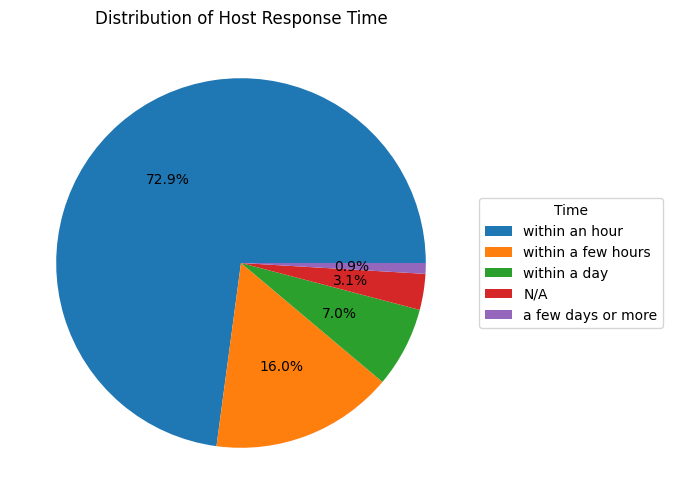

In [ ]:
plt.figure(figsize=(10,6))
plt.pie(dublin_merged_df.host_response_time.value_counts(), autopct='%1.1f%%')
plt.title('Distribution of Host Response Time')
plt.legend(labels = dublin_merged_df.host_response_time.value_counts().index, title="Time", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
plt.show()

From the pie chart above, we can see that most host responds to request quickly with a vast majority of 76.4% responding within an hour, we can also see that 18.1% of host responds within few hours and finally we can see that only 0.8% responds in days, these people might be very new hosts or host that are not so active on the platform. This can be a key selling point for customers who would love quick response and prompt communication from host

**Superhost Distribution**

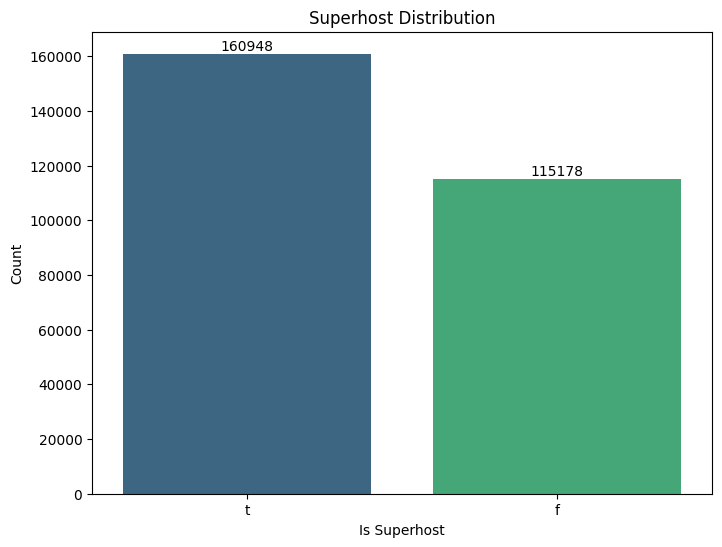

In [ ]:
# Create the barplot
plt.figure(figsize=(8,6))

x = dublin_merged_df.host_is_superhost.value_counts().index
y = dublin_merged_df.host_is_superhost.value_counts().values

sns.barplot(x=x, y=y, palette='viridis')

# Add values on top of the bars
for i in range(len(x)):
    plt.text(i, y[i] + 50, str(y[i]), ha='center', va='bottom')

# Add title and labels
plt.title('Superhost Distribution')
plt.ylabel('Count')
plt.xlabel('Is Superhost')

# Display the plot
plt.show()

The bar chart shows that most of the host are superhosts with a staggering 160948

**Host ID Verification**

The pie chart above shows that 97.9% of AirBnb hosts are verified hence can be trusted.

**Neighbourhood**

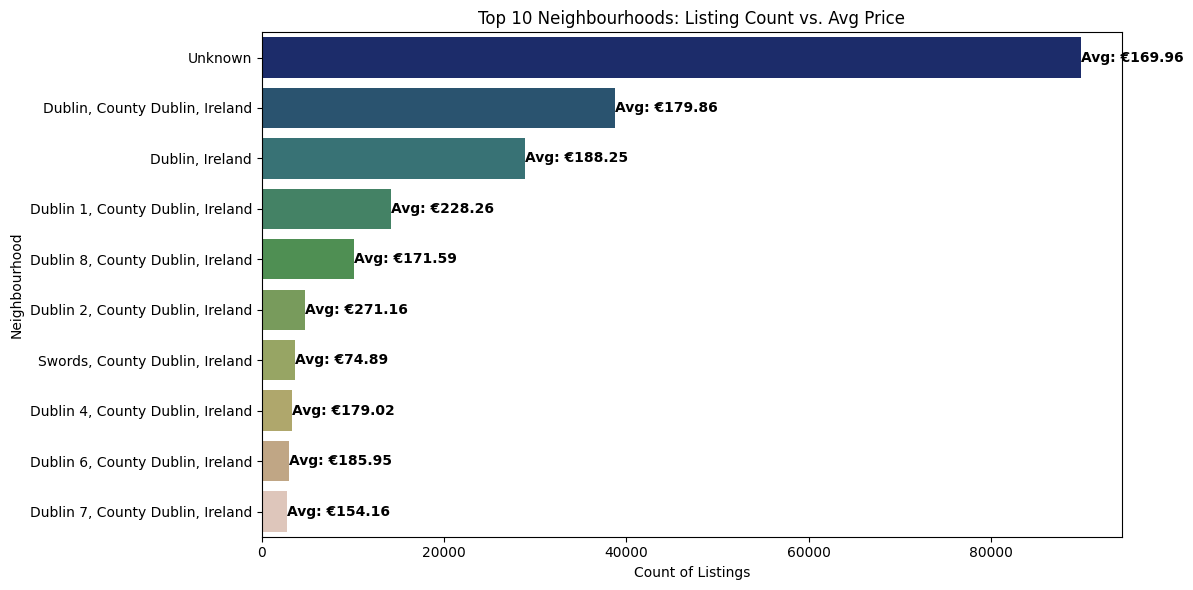

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get the top 10 neighbourhoods by count
top_10 = dublin_merged_df['neighbourhood'].value_counts().head(10)
top_10_names = top_10.index

# 2. Calculate average price for those specific neighbourhoods
avg_prices = dublin_merged_df[dublin_merged_df['neighbourhood'].isin(top_10_names)].groupby('neighbourhood')['price'].mean().reindex(top_10_names)

# 3. Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10.values, y=top_10_names, palette="gist_earth")

# 4. Add average price labels to the end of the bars
for i, (count, price) in enumerate(zip(top_10.values, avg_prices.values)):
    ax.text(count + 1, i, f'Avg: €{price:.2f}', va='center', fontweight='bold')

plt.title('Top 10 Neighbourhoods: Listing Count vs. Avg Price')
plt.xlabel('Count of Listings')
plt.ylabel('Neighbourhood')
plt.tight_layout()
plt.show()


We can see that Dublin City has the most listings and higher average price

- The heatmap above shows that the highest concentration (86071 listings) appears to be in the central Dublin City area.

- Airbnbs are heavily concentrated in the tourist-friendly coastal areas and city center, with significantly less activity in the inland regions.

**Property Type**

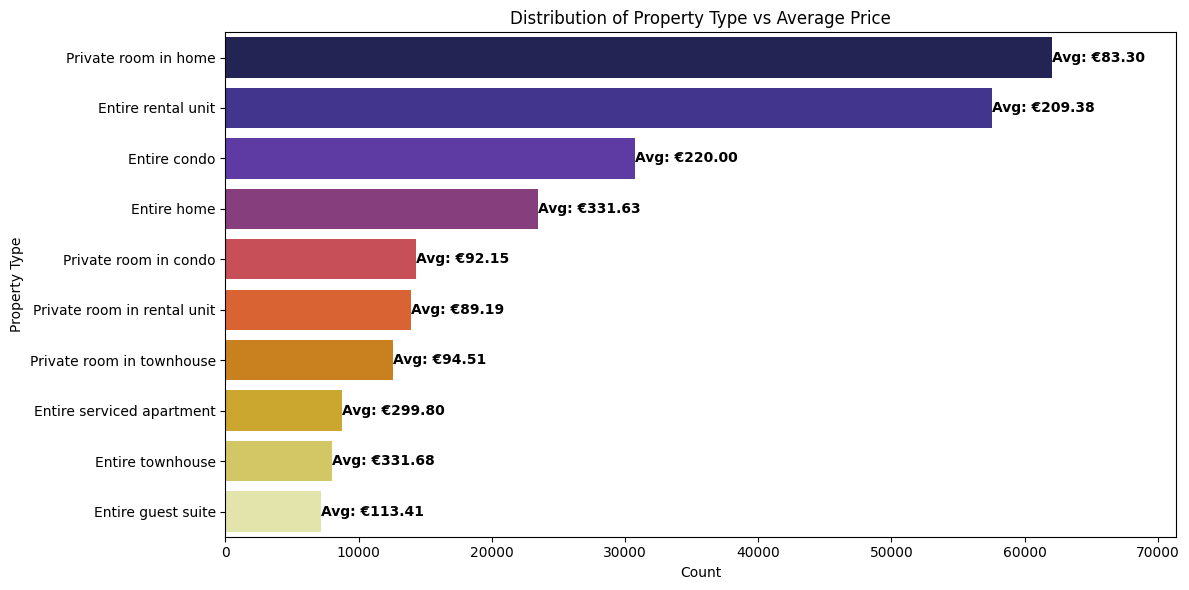

In [ ]:
# 1. Get the top 10 property types by count
top_10_props = dublin_merged_df['property_type'].value_counts().head(10)
top_10_names = top_10_props.index

# 2. Calculate average price for these property types
avg_prices = dublin_merged_df[dublin_merged_df['property_type'].isin(top_10_names)].groupby('property_type')['price'].mean().reindex(top_10_names)

# 3. Create the Plot
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=top_10_props.values, y=top_10_names, palette="CMRmap")

# 4. Add the Average Price as text on the bars
for i, (count, price) in enumerate(zip(top_10_props.values, avg_prices.values)):
    ax.text(count + 5, i, f'Avg: €{price:.2f}', va='center', fontweight='bold', color='black')

plt.title('Distribution of Property Type vs Average Price')
plt.ylabel('Property Type')
plt.xlabel('Count')
plt.xlim(0, top_10_props.max() * 1.15) # Add space for the text labels
plt.tight_layout()
plt.show()


- This bar chart shows the distribution of property types. The most common is "Private room in home", followed by "Entire rental unit", while types like "Private room in rental unit" and "Entire townhouse" are the least common. Overall, private rooms and entire units dominate the listings.


- The chart shows that most listings (131,608) are not instantly bookable (f), while a smaller portion (42,949) are instantly bookable (t). Instant booking is less common overall.

**Price Distribution**

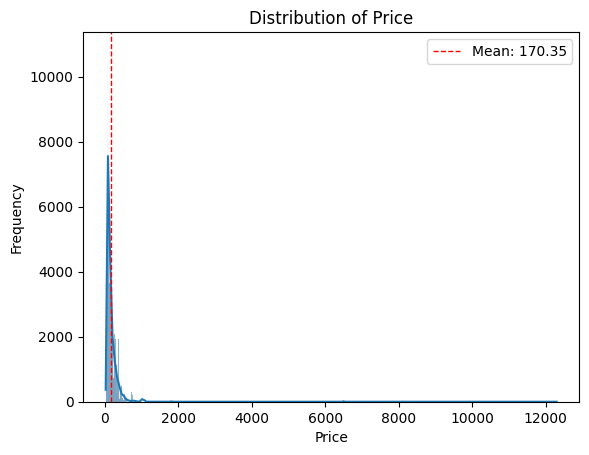

In [ ]:
# mean of the 'price' column
mean_value = dublin_merged_df['price'].mean()

# histogram
sns.histplot(dublin_merged_df['price'], kde=True)

# Add a vertical line at the mean
plt.axvline(mean_value, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {mean_value:.2f}')

# Add legend and labels
plt.legend()
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Distribution of Price')

plt.show();

The price distribution is right-skewed, with most listings priced below £200. The average price is £168.47, but higher-priced outliers pull the mean to the right.

### Feature engineer to include new column

**Sentiment Analysis (Review Comments)**

To better understand the sentiments provided in the reviews dataset we'll use the vadersentiment analyzer to pick up on sentiments in form of compound scores. This feature, named compound_scores, quantifies the overall sentiment polarity of each comment, providing a numeric representation of sentiment strength and orientation (positive, negative, or neutral). The sentiment scores were derived using the VADER (Valence Aware Dictionary and sEntiment Reasoner) sentiment analysis tool, which is particularly effective for analyzing social media text and short informal text inputs. VADER returns four sentiment metrics for a given piece of text: positive, negative, neutral, and compound. The compound score is a normalized, weighted composite score that summarizes the overall sentiment of the text on a continuous scale from -1 (most negative) to +1 (most positive).

In [ ]:
# initialize vader Sentiment Analyzer
analyzer = SentimentIntensityAnalyzer()

In [ ]:
# feature engineer and introduce a new column sentiment score
dublin_merged_df['compound_scores'] = dublin_merged_df['comments'].apply(lambda x: analyzer.polarity_scores(x)['compound'])

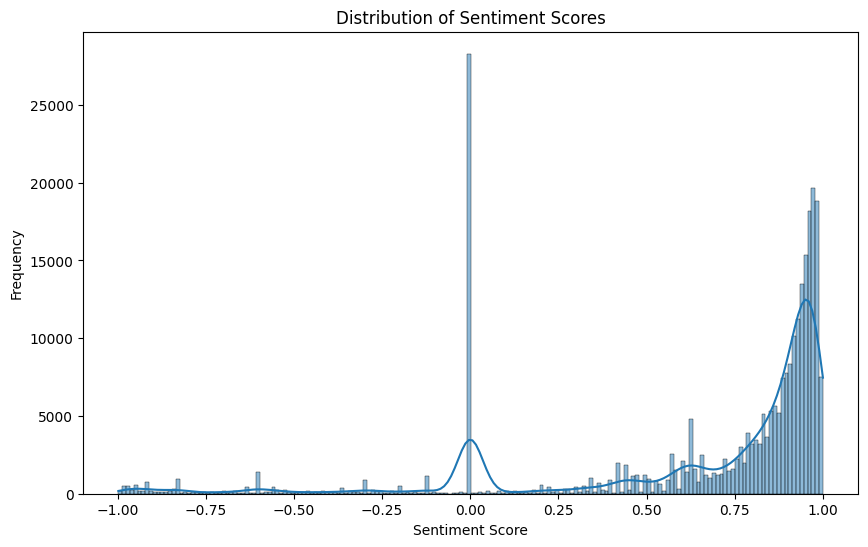

In [ ]:
# check the distribution of sentiment scores
plt.figure(figsize=(10, 6))
sns.histplot(dublin_merged_df['compound_scores'], kde=True)
plt.title('Distribution of Sentiment Scores')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency')
plt.show()

- Negative Scores (-1 to 0): Shows negative sentiment.
- Positive Scores (0 to +1): Show positive sentiment.
- Neutral Score (0): neutral, with no strong emotion.

The sentiment score distribution is skewed strongly positive, with a large spike near 1.0, indicating most reviews are highly positive. There's also a notable peak at 0, suggesting some neutral or ambiguous reviews. Negative sentiments are relatively rare.

- This indicates that most comments express positive sentiments.
- A noticeable spike around the 0 score suggests that many comments are neutral or lack strong sentiment.
- Negative sentiment scores appear far less frequent, indicating relatively few strongly negative comments.

### Bivariate Analysis

**Monthly trend in price**

Next, we'll create a line chart to show trends over time. We'll group the data by month. first, let's extract the month from the date column.

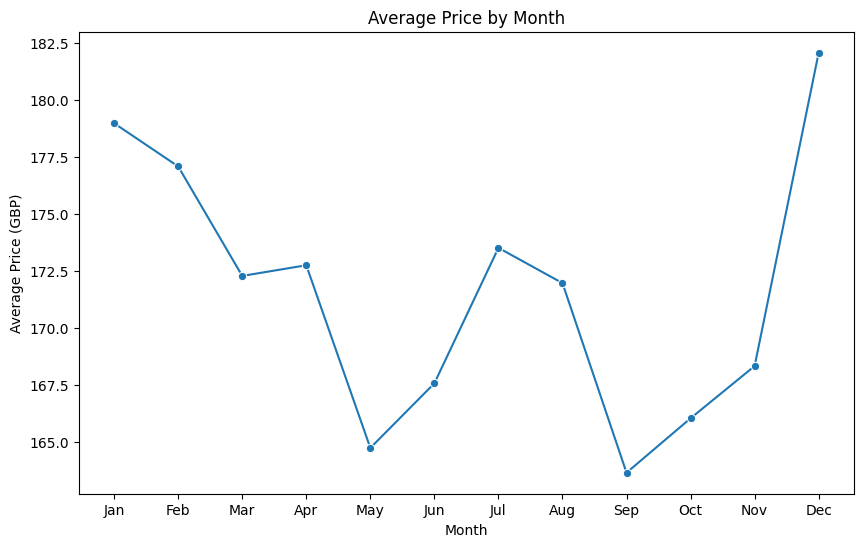

In [ ]:
# month
dublin_merged_df['month'] = dublin_merged_df['date'].dt.month

# Calculate average price per month
avg_price_per_month = dublin_merged_df.groupby('month')['price'].mean().reset_index()

# Create a line plot
plt.figure(figsize=(10,6))
sns.lineplot(x='month', y='price', data=avg_price_per_month, marker='o')

# labels and title
plt.title('Average Price by Month')
plt.xlabel('Month')
plt.ylabel('Average Price (GBP)')
plt.xticks(ticks=range(1, 13), labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
# Show the plot
plt.show();

Alot can be seen in this trend. As it clearly shows that there's Airbnb listings boom during the holiday periods and we can see from the chart that theres a spike both in January and December and lowest in September.

**Average Price by Season**

Now, we'll analyze seasonal variations in prices. First, we'll create a season column based on the listing dates, then use a bar plot to visualize the average price for each season. We'll categorize each month into a season (winter, spring, summer, autumn). We use the Northern Hemisphere, because Dublin falls under that Hemisphere so it follows the standard meteorological seasons, which are:
- Winter: December, January, February.
- Spring: March, April, May.
- Summer: June, July, August.
- Autumn: 	September, October, November.

In [ ]:
# Ensuring date column is in datetime format
dublin_merged_df['date'] = pd.to_datetime(dublin_merged_df['date'])

# function to categorize seasons
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Autumn'

# Apply the function to create a 'season' column
dublin_merged_df['season'] = dublin_merged_df['date'].dt.month.apply(get_season)

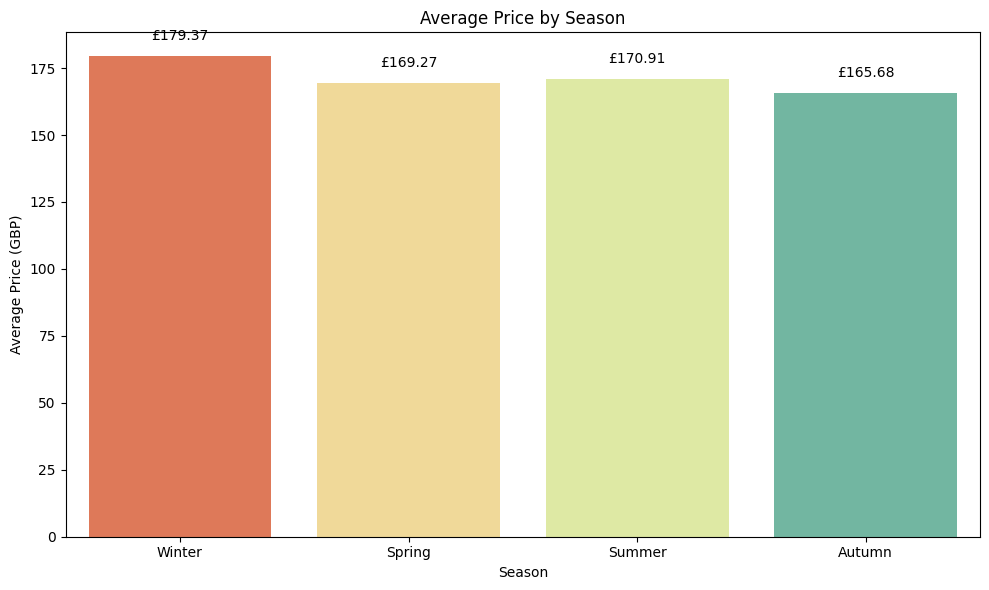

In [ ]:
# Ensure 'season' is a category with proper order
season_order = ['Winter', 'Spring', 'Summer', 'Autumn']
dublin_merged_df['season'] = pd.Categorical(dublin_merged_df['season'], categories=season_order, ordered=True)

# Calculate average price per season
avg_price_per_season = (
    dublin_merged_df
    .groupby('season')['price']
    .mean()
    .reset_index()
    .sort_values(by='price')
)

# Plotting
plt.figure(figsize=(10, 6))
ax = sns.barplot(x='season', y='price', data=avg_price_per_season, palette='Spectral')

# Add labels on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 5,
        f"£{height:.2f}",
        ha='center',
        va='bottom',
        color='black'
    )

# Add labels and title
ax.set_title('Average Price by Season')
ax.set_xlabel('Season')
ax.set_ylabel('Average Price (GBP)')

plt.tight_layout()
plt.show()


This chart shows the average rental price by season in Dublin:

1. Winter (£176.47) has the highest average price.

2. Autumn (£163.30) has the lowest average price.

3. Summer (£169.51) and Spring (£167.96) are in between.

Rental prices tend to peak in winter and dip slightly in autumn, with relatively stable pricing across the other seasons.


This scatter plot shows the relationship between the price and the average rating of properties, with prices up to £20,000.

Key observations:

- The majority of properties, regardless of price, have high average ratings, clustering around 4.5 to 5.0.
- Fewer properties have lower average ratings (below 4.0), spread across various price points.
- No clear trend indicates that higher prices correlate with higher average ratings or vice versa.
- There's a dense concentration of items with prices below £500 and ratings between 4.5 and 5.0.
- This scatter plot shows that high ratings are common across a wide range of prices.

Higher price does not guarantee a higher rating. Quality (as perceived by guests) appears largely independent of price, especially at the lower to mid price range.

**Distribution of Price by Property Type**

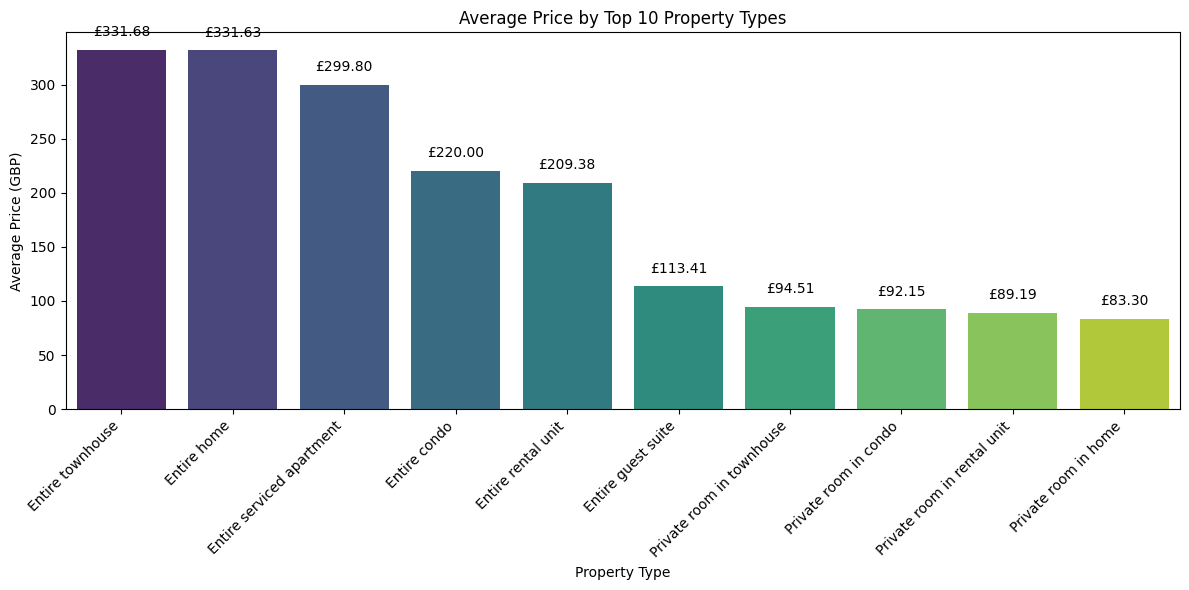

In [ ]:
# Count the occurrences of each property type
property_counts = dublin_merged_df['property_type'].value_counts()

# Select the top 10 most common property types
top_property_types = property_counts.nlargest(10).index

# Filter data for top property types and calculate average price
avg_price_per_property_type = (
    dublin_merged_df[dublin_merged_df['property_type'].isin(top_property_types)]
    .groupby('property_type')['price']
    .mean()
    .reset_index()
    .sort_values(by='price', ascending=False)
)

# Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    x='property_type',
    y='price',
    data=avg_price_per_property_type,
    palette='viridis'
)

# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Add price labels on top of bars
for bar in ax.patches:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 10,
        f"£{height:.2f}",
        ha='center',
        va='bottom',
        fontsize=10
    )

# Add labels and title
ax.set_title('Average Price by Top 10 Property Types')
ax.set_xlabel('Property Type')
ax.set_ylabel('Average Price (GBP)')

plt.tight_layout()
plt.show()

Drop host_since, first_review and last_review columns as we do not need them anymore

In [ ]:
#cols_to_drop = ['host_since', 'first_review', 'last_review']
#dublin_merged_df = dublin_merged_df.drop(columns=[col for col in cols_to_drop if col in dublin_merged_df.columns])

### Multivariate Analysis
**Host Joining Airbnb**

In [ ]:
print(f"Of the Airbnb hosts that are still listing on the site, the first joined on {min(dublin_merged_df.host_since).strftime('%d %B %Y')}, and the most recent joined on {max(dublin_merged_df.host_since).strftime('%d %B %Y')}.")

Of the Airbnb hosts that are still listing on the site, the first joined on 25 November 2009, and the most recent joined on 03 June 2025.


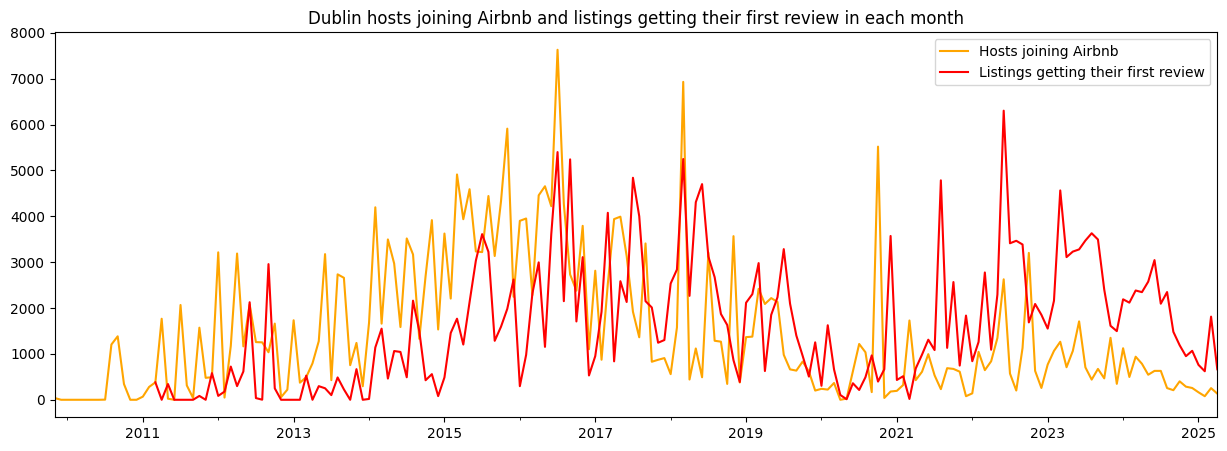

In [ ]:
plt.figure(figsize=(15,5))
dublin_merged_df.set_index('host_since').resample('MS').size().plot(label='Hosts joining Airbnb', color='orange')
dublin_merged_df.set_index('first_review').resample('MS').size().plot(label='Listings getting their first review', color='red')
plt.title('Dublin hosts joining Airbnb and listings getting their first review in each month')
plt.legend()
plt.xlim('2009-11-25', '2025-04-30') # Limiting to whole months
plt.xlabel('')
plt.ylabel('')
plt.show()

**Correlation Matrix**

The heatmap will help us visualize the correlations between numeric variables in the dataset, highlighting how they relate to each other.

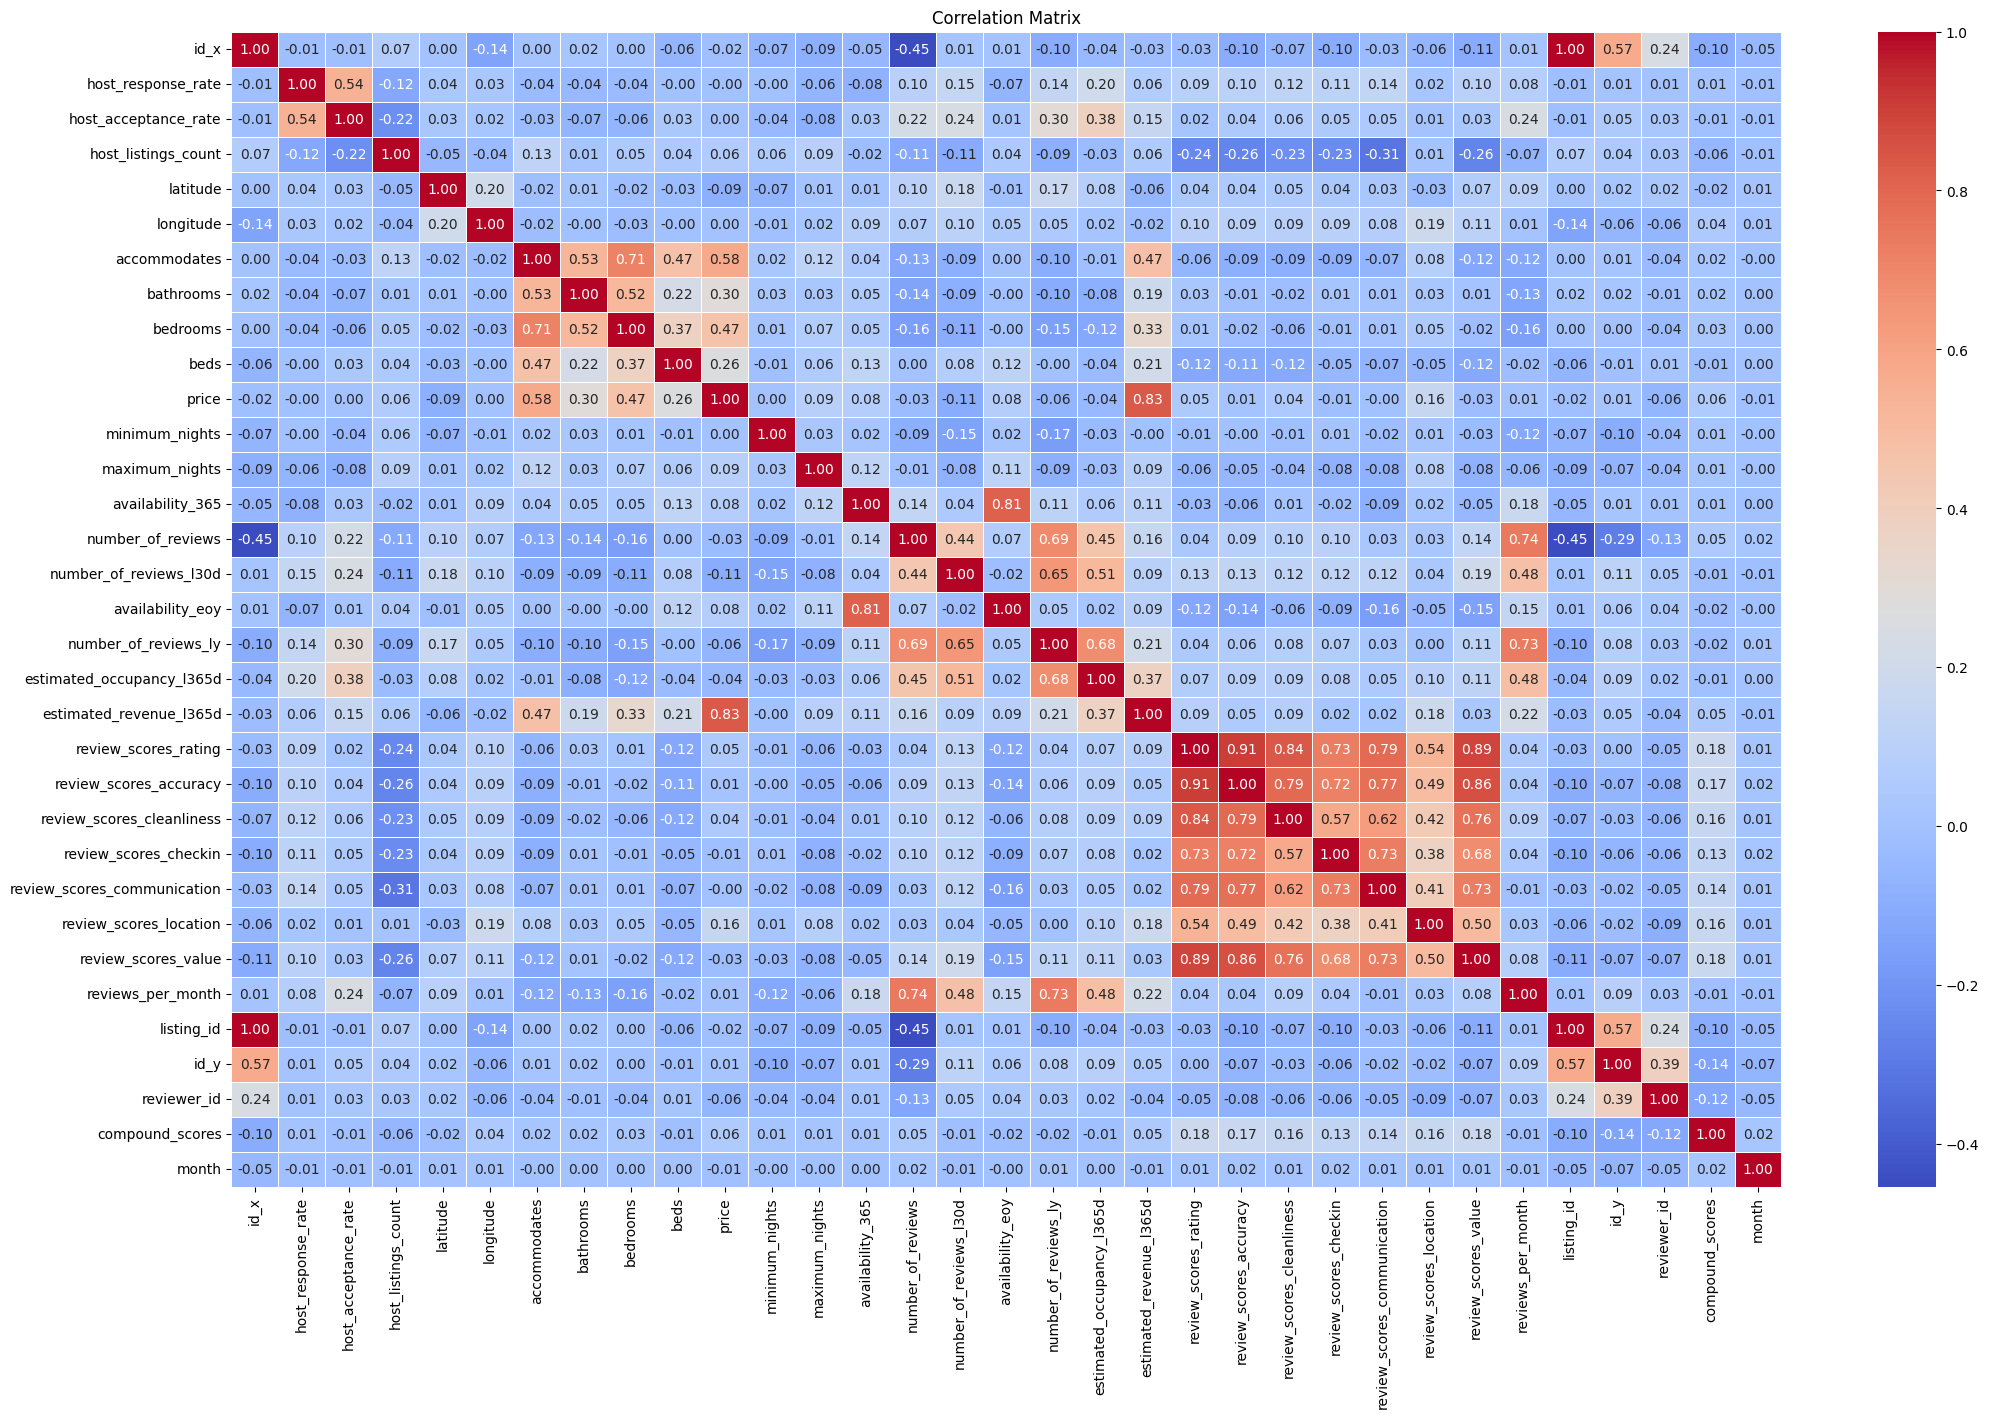

In [ ]:
# Filter the dataframe to select only numeric columns
numeric_df = dublin_merged_df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix
plt.figure(figsize=(25, 15))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

From the correlation metrics, we can see the following strong predictors of price; Accommodates (corr = 0.68), Estimated Revenue (365d) (corr = 0.81) – highly correlated, but could cause leakage if it's derived from price, Bedrooms (0.52), Bathrooms (0.40), Beds (0.24), Number of Reviews (0.20) – moderately helpful, could reflect popularity, Host Total Listings Count (0.17) – may reflect host scale or professionalism

While the following to be cautious with, which are
Estimated revenue, Reviewer ID, Host ID ( identifiers that are not useful)

Latitude/Longitude(This can only be used if converted to neighborhoods, but we are not looking at that in this case)

Ratings (Ovarall_rating, compound_scores) – low correlation; may not help much. We would be including this in our selected features


**Statistical validation (Anova Test)**

Now, we will conduct an ANOVA test to analyze how various factors influence the pricing of Airbnb listings, allowing us to identify significant predictors of price.

In [ ]:
from statsmodels.formula.api import ols
import statsmodels.api as sm


# Define the formula (C() denotes categorical features)
formula = (
    'log_price ~ C(host_response_rate) + C(host_is_superhost) + C(neighbourhood) + '
    'C(property_type) + C(room_type) + accommodates + bathrooms + bedrooms + maximum_nights + '
    'beds + number_of_reviews + C(instant_bookable) + review_scores_rating + review_scores_cleanliness + review_scores_location + compound_scores + C(season)'
)


#  Fit the model
model = ols(formula, data=dublin_merged_df).fit()

# Perform ANOVA (Type 2)
anova_table = sm.stats.anova_lm(model, typ=2)

# 4. Display results
print("ANOVA Analysis Results:")
print(anova_table)

ANOVA Analysis Results:
                                 sum_sq        df             F         PR(>F)
C(host_response_rate)        742.119869      59.0    139.218456   0.000000e+00
C(host_is_superhost)           1.282056       1.0     14.189977   1.652828e-04
C(neighbourhood)            4810.285070     238.0    223.701359   0.000000e+00
C(property_type)            5469.607725      48.0   1261.216685   0.000000e+00
C(room_type)                  56.866298       3.0    209.801440  6.080250e-136
C(instant_bookable)           50.861761       1.0    562.945246  2.564345e-124
C(season)                      3.835164       3.0     14.149381   3.228057e-09
accommodates                4365.960268       1.0  48323.072923   0.000000e+00
bathrooms                      0.045878       1.0      0.507783   4.761006e-01
bedrooms                     587.407622       1.0   6501.511609   0.000000e+00
maximum_nights                 4.947195       1.0     54.756260   1.368287e-13
beds                        

Property size, especially accommodates and bedrooms, has the strongest influence on price.
Customer perception, captured by avg_rating, also plays a major role in pricing.
Listing characteristics such as property_type and neighbourhood significantly explain price differences.
Host-related factors and seasonal effects matter, but their impact is relatively smaller.

**Data Aggregation**

The merged dataframe, each listing can have multiple reviews, leading to duplicate rows for the same listing. To create our baseline linear regression model, we'll first aggregate the data to ensure each listing appears only once.

In [ ]:
# Aggregate data to avoid duplicate rows caused by multiple reviews for the same property
dublin_aggregated_df = (
    dublin_merged_df
    .groupby('id_x')
    .agg({
        #'host_id': 'first', # Host-related features are constant per listing, so we take the first occurrence
        'host_response_rate': 'first',
        'host_is_superhost': 'first',
        'host_listings_count': 'first',
        'accommodates': 'mean', # we average numerical features across all property info
        'bedrooms': 'mean',
        'beds': 'mean',
        'maximum_nights': 'mean',
        'price': 'first', # is taken as the first occurrence since it is consistent across reviews
        'review_scores_rating': 'mean', # averaged across all reviews
        'review_scores_cleanliness': 'mean',
        'review_scores_location': 'mean',
        'number_of_reviews': 'sum',
        'neighbourhood': 'first',
        'property_type': 'first'
    })
    .reset_index()
)

The dataset is grouped by the property identifier id_x this is to avoid duplicate rows caused by multiple reviews for the same listing.
For each group, the following features where aggregated as follows;
- **Host-related features** (host_id, host_response_rate, host_is_superhost, host_listings_count) are assumed constant for each listing and thus the first occurrence is taken.
- **Numerical property features** (accommodates, bathrooms, bedrooms, beds) are averaged across all rows to account for possible minor variations.
- **Price** is taken as the first occurrence, assuming it remains consistent for the listing.
- **Average rating** is calculated as the mean of all review ratings.
- **Number of reviews** is summed to capture the total review count for each listing.
- **Categorical features** (neighbourhood_cleansed, property_type) are taken from the first occurrence.

Without aggregation, the model might incorrectly treat each review as an independent data point, leading to Overrepresentation of popular listings meaning Properties with many reviews would have disproportionately more rows, skewing the model, Data leakage meaning Repeated entries of the same property with similar features can cause the model to overfit, Inconsistent feature values meaning that  Some features (like ratings or number of reviews) vary across reviews, so a single-row summary is needed to capture the true property profile.

By aggregating the data, We consolidate all reviews into one representative row per listing, maintaining the unique identifier, compute meaningful summary statistics (e.g., average rating, total number of reviews) that better represent the property’s overall characteristics, ensure that constant features (e.g., host ID, neighborhood) remain consistent for each listing and ensure our results in a clean, unbiased, and stable dataset that improves the reliability and accuracy of the predictive model.

Summary

The dataset was aggregated at the listing level (id_x) to ensure each property is represented by a single, consistent row using appropriate summary statistics for different feature types.

This prevents overrepresentation, data leakage, and inconsistency, resulting in a cleaner, more reliable dataset that improves model accuracy and stability.
### Feature Encoding

In [ ]:
# Counts of each unique neighbourhood
print(dublin_merged_df['neighbourhood'].value_counts())

# Counts of each unique property type
print(dublin_merged_df['property_type'].value_counts())


neighbourhood
Unknown                                 89858
Dublin, County Dublin, Ireland          38810
Dublin, Ireland                         28876
Dublin 1, County Dublin, Ireland        14137
Dublin 8, County Dublin, Ireland        10122
                                        ...  
Cruagh Manor, County Dublin, Ireland        4
County Meath, Ireland                       3
Ballyboughal, County Dublin, Ireland        3
Celbridge, County Kildare, Ireland          2
North Wall, County Dublin, Ireland          2
Name: count, Length: 239, dtype: int64
property_type
Private room in home                  62034
Entire rental unit                    57573
Entire condo                          30770
Entire home                           23437
Private room in condo                 14335
Private room in rental unit           13913
Private room in townhouse             12572
Entire serviced apartment              8742
Entire townhouse                       8029
Entire guest suite             

In [ ]:
print("Unique neighbourhoods:", dublin_merged_df['neighbourhood'].nunique())
print("Unique property types:", dublin_merged_df['property_type'].nunique())


Unique neighbourhoods: 239
Unique property types: 49


In [ ]:
# Frequency Encoding for 'neighbourhood' and 'property_type'
# Each had 222 and 40 unique values respectively, therefore couldn't use one-hot encoding
for col in ['neighbourhood', 'property_type']:
    freq_encoding = dublin_aggregated_df[col].value_counts(normalize=True)
    dublin_aggregated_df[f'{col}_freq'] = dublin_aggregated_df[col].map(freq_encoding)

The code iterates over the two categorical columns 'neighbourhood' and 'property_type' and we calculate frequency encoding such that For each column, value_counts(normalize=True) computes the relative frequency (proportion) of each unique category within that column. For example, if 'Dublin City' appears in 30% of listings, its frequency becomes 0.3 and then finally map the frequencies back to the dataframe by using .map(freq_encoding), the code creates a new column named '{col}_freq' (e.g., 'neighbourhood_cleansed_freq') that replaces each category with its corresponding frequency value.

In [ ]:
# Encode 'host_is_superhost' as binary (0 and 1)
dublin_aggregated_df['host_is_superhost'] = dublin_aggregated_df['host_is_superhost'].map({'t': 1, 'f': 0})

In [ ]:
dublin_aggregated_df.head()

,id_x,host_response_rate,host_is_superhost,host_listings_count,accommodates,bedrooms,beds,maximum_nights,price,review_scores_rating,review_scores_cleanliness,review_scores_location,number_of_reviews,neighbourhood,property_type,neighbourhood_freq,property_type_freq
0,44077,100.0,1,2.0,2.0,1.0,2.0,30.0,76.0,4.81,4.76,4.68,144400,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
1,85156,100.0,1,2.0,2.0,1.0,1.0,21.0,91.0,4.81,4.76,4.64,117649,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
2,159889,100.0,0,3.0,1.0,1.0,1.0,14.0,45.0,4.75,4.71,4.65,202500,"Dublin, Ireland",Private room in home,0.031138,0.223342
3,165828,75.0,0,4.0,5.0,1.0,3.0,365.0,256.0,4.67,4.73,4.40,7056,"Dublin, Ireland",Entire rental unit,0.031138,0.231855
4,165829,75.0,0,4.0,5.0,1.0,3.0,365.0,228.0,4.72,4.76,4.40,7225,"Dublin, Ireland",Entire rental unit,0.031138,0.231855


In [ ]:
# Clean 'host_response_rate' by removing '%' and converting to numeric
dublin_aggregated_df['host_response_rate'] = (
    dublin_aggregated_df['host_response_rate']
    .astype(float) / 100  # Convert to float and scale to [0, 1]
)

In [ ]:
dublin_aggregated_df.head()

,id_x,host_response_rate,host_is_superhost,host_listings_count,accommodates,bedrooms,beds,maximum_nights,price,review_scores_rating,review_scores_cleanliness,review_scores_location,number_of_reviews,neighbourhood,property_type,neighbourhood_freq,property_type_freq
0,44077,1.00,1,2.0,2.0,1.0,2.0,30.0,76.0,4.81,4.76,4.68,144400,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
1,85156,1.00,1,2.0,2.0,1.0,1.0,21.0,91.0,4.81,4.76,4.64,117649,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
2,159889,1.00,0,3.0,1.0,1.0,1.0,14.0,45.0,4.75,4.71,4.65,202500,"Dublin, Ireland",Private room in home,0.031138,0.223342
3,165828,0.75,0,4.0,5.0,1.0,3.0,365.0,256.0,4.67,4.73,4.40,7056,"Dublin, Ireland",Entire rental unit,0.031138,0.231855
4,165829,0.75,0,4.0,5.0,1.0,3.0,365.0,228.0,4.72,4.76,4.40,7225,"Dublin, Ireland",Entire rental unit,0.031138,0.231855


In [ ]:
# Drop original 'neighbourhood' and 'property_type' columns,
# because frequency-encoded columns are now included
dublin_encoded_df = dublin_aggregated_df.drop(['neighbourhood', 'property_type'], axis=1)

In [ ]:
dublin_aggregated_df.head()

,id_x,host_response_rate,host_is_superhost,host_listings_count,accommodates,bedrooms,beds,maximum_nights,price,review_scores_rating,review_scores_cleanliness,review_scores_location,number_of_reviews,neighbourhood,property_type,neighbourhood_freq,property_type_freq
0,44077,1.00,1,2.0,2.0,1.0,2.0,30.0,76.0,4.81,4.76,4.68,144400,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
1,85156,1.00,1,2.0,2.0,1.0,1.0,21.0,91.0,4.81,4.76,4.64,117649,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
2,159889,1.00,0,3.0,1.0,1.0,1.0,14.0,45.0,4.75,4.71,4.65,202500,"Dublin, Ireland",Private room in home,0.031138,0.223342
3,165828,0.75,0,4.0,5.0,1.0,3.0,365.0,256.0,4.67,4.73,4.40,7056,"Dublin, Ireland",Entire rental unit,0.031138,0.231855
4,165829,0.75,0,4.0,5.0,1.0,3.0,365.0,228.0,4.72,4.76,4.40,7225,"Dublin, Ireland",Entire rental unit,0.031138,0.231855


In [ ]:
dublin_encoded_df.head()

,id_x,host_response_rate,host_is_superhost,host_listings_count,accommodates,bedrooms,beds,maximum_nights,price,review_scores_rating,review_scores_cleanliness,review_scores_location,number_of_reviews,neighbourhood_freq,property_type_freq
0,44077,1.00,1,2.0,2.0,1.0,2.0,30.0,76.0,4.81,4.76,4.68,144400,0.000448,0.004032
1,85156,1.00,1,2.0,2.0,1.0,1.0,21.0,91.0,4.81,4.76,4.64,117649,0.000448,0.004032
2,159889,1.00,0,3.0,1.0,1.0,1.0,14.0,45.0,4.75,4.71,4.65,202500,0.031138,0.223342
3,165828,0.75,0,4.0,5.0,1.0,3.0,365.0,256.0,4.67,4.73,4.40,7056,0.031138,0.231855
4,165829,0.75,0,4.0,5.0,1.0,3.0,365.0,228.0,4.72,4.76,4.40,7225,0.031138,0.231855


In [ ]:
dublin_encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4464 entries, 0 to 4463
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_x                       4464 non-null   int64  
 1   host_response_rate         4464 non-null   float64
 2   host_is_superhost          4464 non-null   int64  
 3   host_listings_count        4464 non-null   float64
 4   accommodates               4464 non-null   float64
 5   bedrooms                   4464 non-null   float64
 6   beds                       4464 non-null   float64
 7   maximum_nights             4464 non-null   float64
 8   price                      4464 non-null   float64
 9   review_scores_rating       4464 non-null   float64
 10  review_scores_cleanliness  4464 non-null   float64
 11  review_scores_location     4464 non-null   float64
 12  number_of_reviews          4464 non-null   int64  
 13  neighbourhood_freq         4464 non-null   float

In [ ]:
dublin_aggregated_df.head()

,id_x,host_response_rate,host_is_superhost,host_listings_count,accommodates,bedrooms,beds,maximum_nights,price,review_scores_rating,review_scores_cleanliness,review_scores_location,number_of_reviews,neighbourhood,property_type,neighbourhood_freq,property_type_freq
0,44077,1.00,1,2.0,2.0,1.0,2.0,30.0,76.0,4.81,4.76,4.68,144400,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
1,85156,1.00,1,2.0,2.0,1.0,1.0,21.0,91.0,4.81,4.76,4.64,117649,"Churchtown, Ireland",Private room in bungalow,0.000448,0.004032
2,159889,1.00,0,3.0,1.0,1.0,1.0,14.0,45.0,4.75,4.71,4.65,202500,"Dublin, Ireland",Private room in home,0.031138,0.223342
3,165828,0.75,0,4.0,5.0,1.0,3.0,365.0,256.0,4.67,4.73,4.40,7056,"Dublin, Ireland",Entire rental unit,0.031138,0.231855
4,165829,0.75,0,4.0,5.0,1.0,3.0,365.0,228.0,4.72,4.76,4.40,7225,"Dublin, Ireland",Entire rental unit,0.031138,0.231855


In [ ]:
# load listings
#test_df = pd.read_csv('dublin_merged_df.csv.gz', compression='gzip')
#test_df.head()

In [ ]:
#dublin_merged_df.to_csv('dublin_merged_df.csv.gz', index=False, compression='gzip')

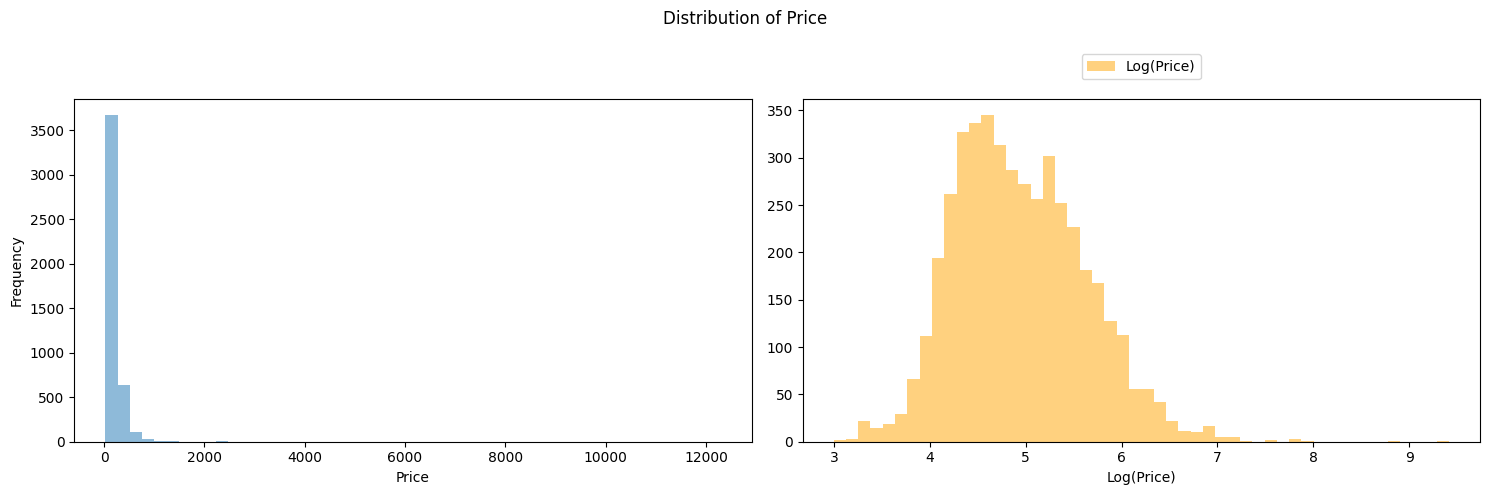

In [ ]:
# split data
X = dublin_encoded_df.drop(['id_x', 'price'], axis=1)
y = dublin_encoded_df['price']

# log transform y variable(price)
y_log = np.log(y)
y_log.name = "log(price)"

# plot the raw y variable and log transformed y variable
fig, ax = plt.subplots(1, 2, figsize=(15, 5))  # figure with 2 subplots

# Plot original price distribution
ax[0].hist(y, bins=50, alpha=0.5, label="Price")
ax[0].set_xlabel("Price")
ax[0].set_ylabel("Frequency")

# Plot log-transformed price distribution
ax[1].hist(y_log, bins=50, color="orange", alpha=0.5, label="Log(Price)")
ax[1].set_xlabel("Log(Price)")

# Add legend
plt.legend(loc="upper center", bbox_to_anchor=(0.5, 1.15))

# main title
plt.suptitle("Distribution of Price")

plt.tight_layout()
plt.show()

The raw prices are right-skewed, with most listings priced under £500, and a few very expensive outliers.  After log transformation, the distribution becomes more normal (bell-shaped) — making it better suited for regression models. Log transformation helps stabilize variance, reduce skewness, and improve model performance.